# Saliency-Driven Gaze Simulation: Saliency Comparison

**Course:** Natural Interaction, Universita degli Studi di Milano, 2026

**Author:** Arash Khosropour

**Supervisors:** Prof. Giuseppe Boccignone

---

## What this notebook shows

We looked into SaccadeJEPA (https://github.com/LumenPallidium/jepa) and found that its saccade targets are selected uniformly at random. The key line in saccade.py is:

```python
translations = torch.empty(b, 2).uniform_(-max_frac, max_frac)  # random
```

There is no content-based attention. SaccadeJEPA is a representation learning model, not a gaze simulator.

if we replace that random line with a learned saliency model trained on real human eye-tracking data, how much does gaze simulation improve?

We compare four saliency sources:

| Source | Description |
|---|---|
| Random | What SaccadeJEPA does -- uniform noise |
| Center bias | Hand-crafted Gaussian at image center, no learning |
| Spectral residual | Classical signal processing (Hou & Zhang, 2007) |
| ResNetSaliency | ResNet-18 backbone trained on FIND fixation data |

In [ ]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import os

from gazejepa.saliency.random import RandomSaliency
from gazejepa.saliency.center_bias import CenterBiasSaliency
from gazejepa.saliency.spectral_residual import SpectralResidualSaliency
from gazejepa.saliency.resnet_saliency import ResNetSaliency
from gazejepa.data.find_dataset import (
    load_frame, load_fixations, get_frame_fixations, 
    rescale_fixations, make_heatmap
)

DATA_ROOT  = 'f:/university/milan/NI/info/Gaze_Jepa/find_dataset'  # Change it according to your local path
notebook_dir = Path.cwd() if 'notebooks' in str(Path.cwd()) else Path.cwd() / 'notebooks'
CHECKPOINT = str(Path.cwd().parent / 'gazejepa' / 'checkpoints' / 'resnet_saliency_best.pt')

# load_frame returns uint8 [0, 255]; divide by 255 to get [0, 1] for the saliency models
def IMAGE_TRANSFORM(frame):
    """Convert numpy uint8 (H, W, 3) [0-255] to float tensor (3, H, W) [0-1]."""
    if isinstance(frame, np.ndarray):
        return torch.from_numpy(frame).permute(2, 0, 1).float().div(255.0)
    return torch.tensor(frame).float().div(255.0)

random_source    = RandomSaliency()
center_source    = CenterBiasSaliency()
classical_source = SpectralResidualSaliency()
learned_source   = ResNetSaliency.load(CHECKPOINT)

SOURCES = [
    (random_source,    'Random (SaccadeJEPA)'),
    (center_source,    'Center bias'),
    (classical_source, 'Spectral residual'),
    (learned_source,   'ResNetSaliency (ours)'),
]

print('Ready.')

## 1. The FIND Dataset

FIND contains eye-tracking data from 39 observers watching 65 multi-face social videos.
For each frame we have the pixel coordinates of where every observer was looking -- this is the ground truth.

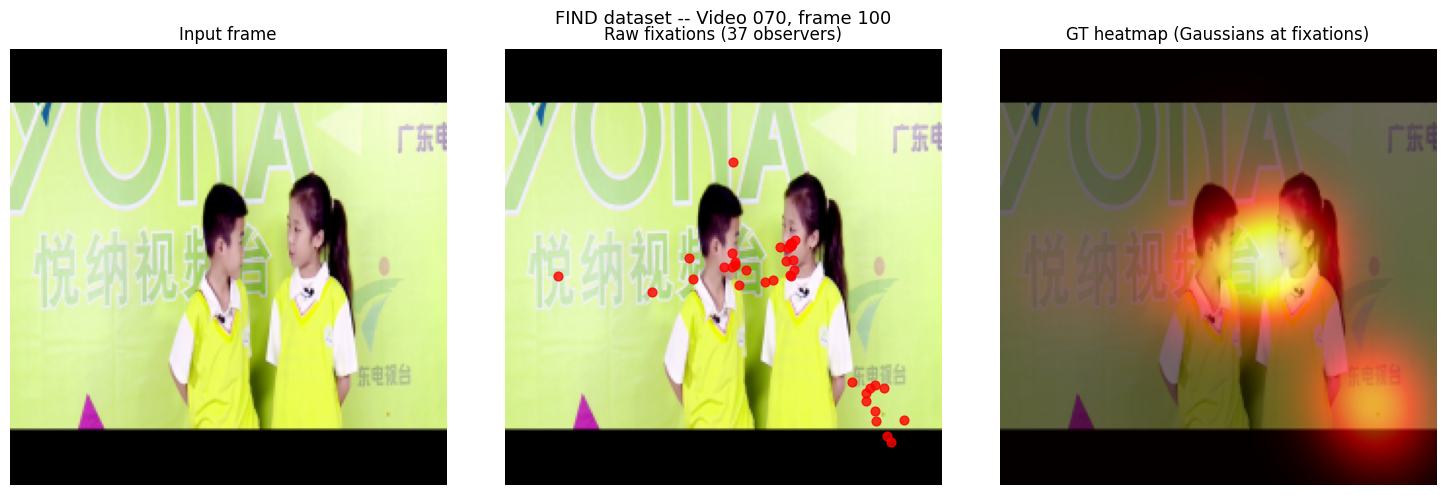

In [27]:
VIDEO_ID  = '070'
FRAME_IDX = 100

frame      = load_frame(DATA_ROOT, VIDEO_ID, FRAME_IDX, size=224)
fix_array  = load_fixations(DATA_ROOT, VIDEO_ID)
raw_fix    = get_frame_fixations(fix_array, FRAME_IDX)
gt_fix     = rescale_fixations(raw_fix, (1280, 720), (224, 224))
gt_heatmap = make_heatmap(gt_fix, 224, 224, sigma=20.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(frame)
axes[0].set_title('Input frame', fontsize=12)
axes[0].axis('off')

axes[1].imshow(frame)
axes[1].scatter(gt_fix[:, 0], gt_fix[:, 1], c='red', s=40, alpha=0.8)
axes[1].set_title(f'Raw fixations ({len(gt_fix)} observers)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(frame)
axes[2].imshow(gt_heatmap, cmap='hot', alpha=0.6)
axes[2].set_title('GT heatmap (Gaussians at fixations)', fontsize=12)
axes[2].axis('off')

plt.suptitle(f'FIND dataset -- Video {VIDEO_ID}, frame {FRAME_IDX}', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Four Saliency Sources on the Same Frame

Each model outputs a probability map over pixels.
The last column is the human GT -- what we want to match.

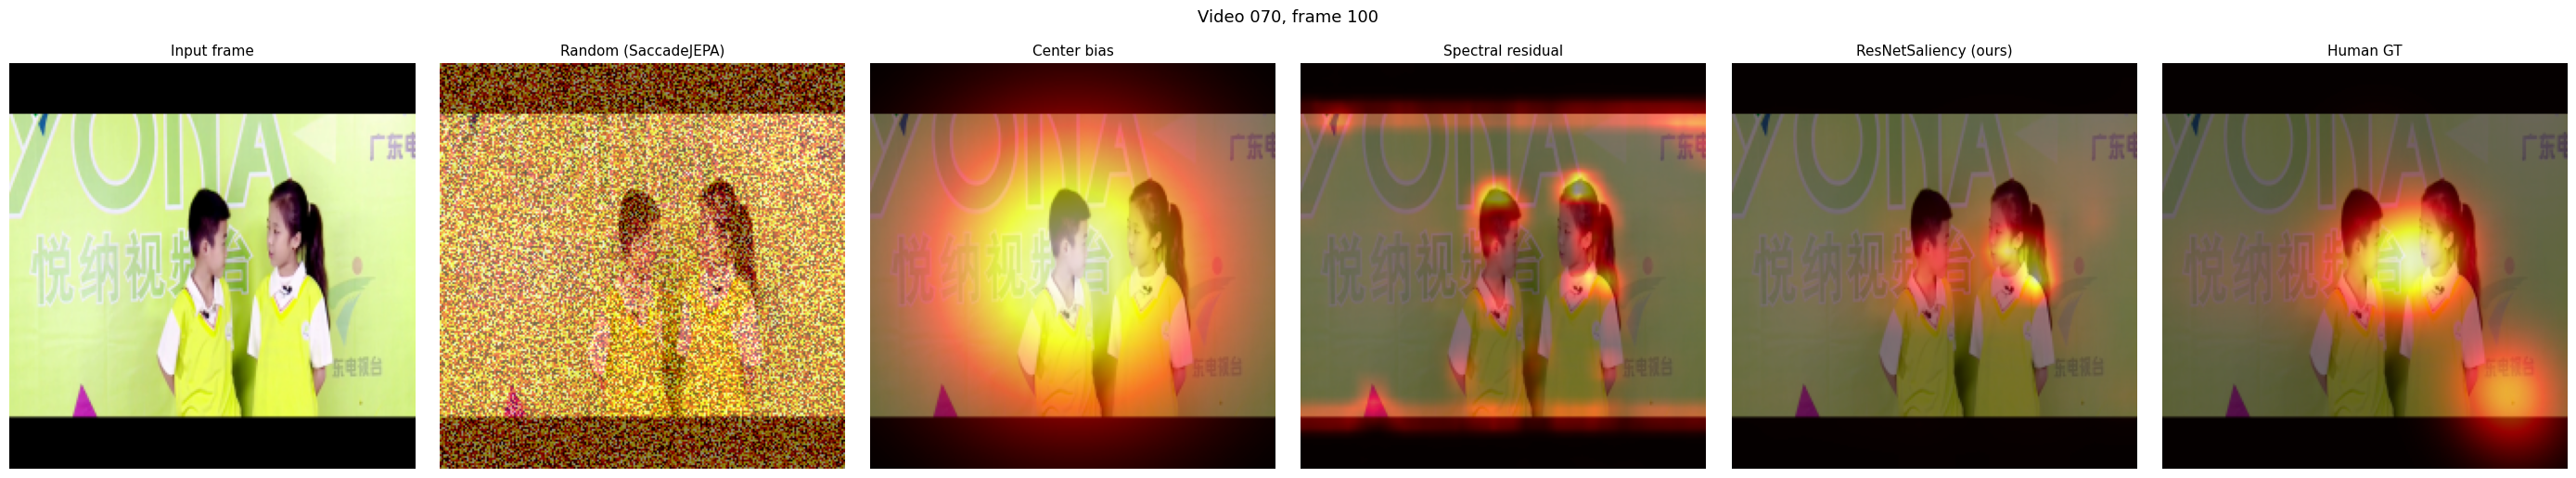

In [28]:
image_tensor = IMAGE_TRANSFORM(frame).unsqueeze(0)

with torch.no_grad():
    saliency_maps = [src(image_tensor)[0].numpy() for src, _ in SOURCES]

fig, axes = plt.subplots(1, 6, figsize=(28, 5))

axes[0].imshow(frame)
axes[0].set_title('Input frame', fontsize=11)
axes[0].axis('off')

for ax, sal, (_, title) in zip(axes[1:5], saliency_maps, SOURCES):
    ax.imshow(frame)
    ax.imshow(sal, cmap='hot', alpha=0.55)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

axes[5].imshow(frame)
axes[5].imshow(gt_heatmap, cmap='hot', alpha=0.6)
axes[5].set_title('Human GT', fontsize=11)
axes[5].axis('off')

plt.suptitle(f'Video {VIDEO_ID}, frame {FRAME_IDX}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../report_arash/figures/saliency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Second Frame -- Different Video

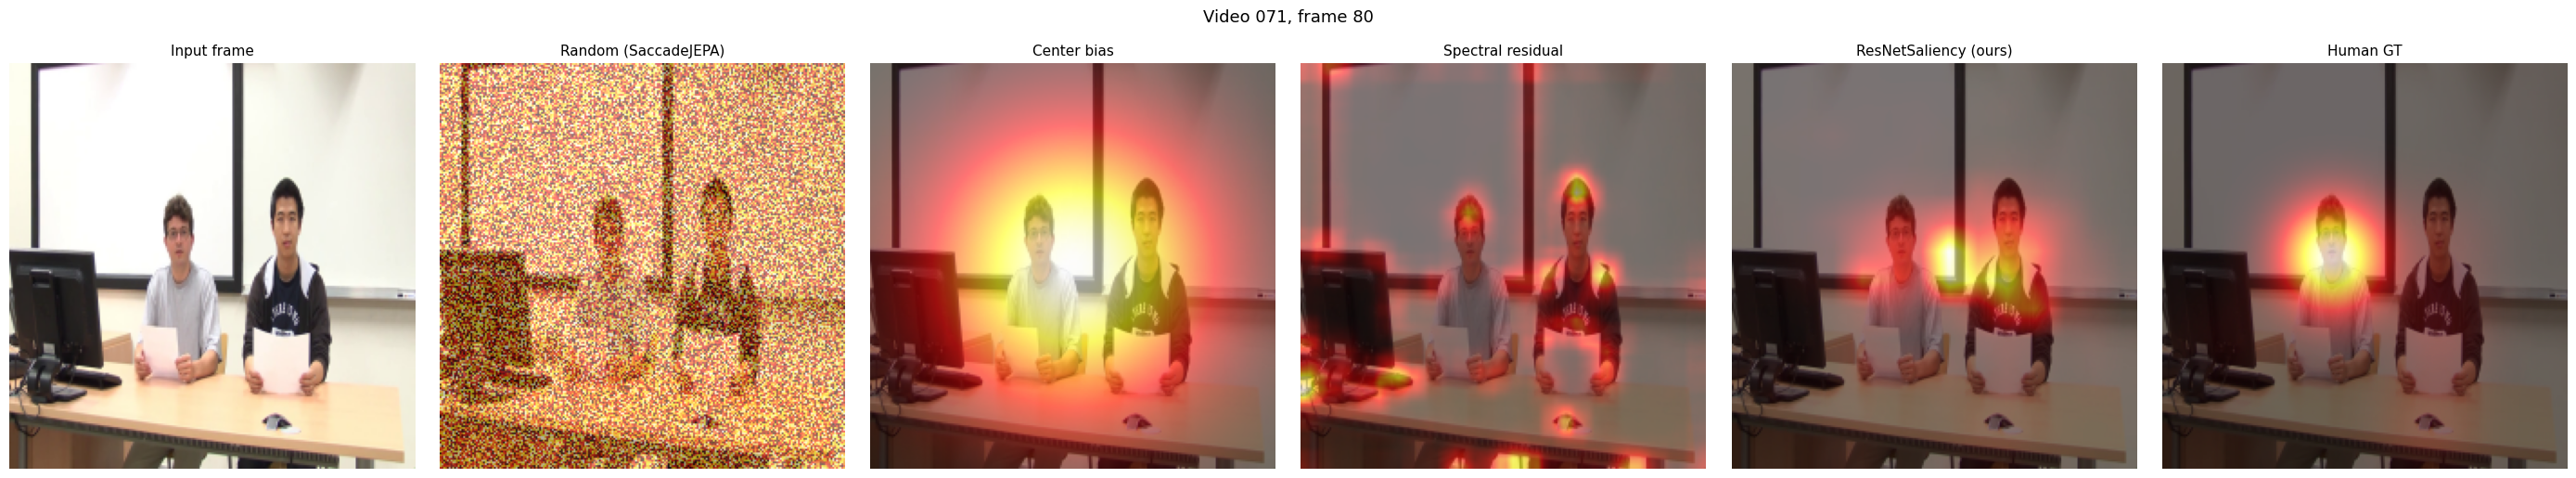

In [29]:
VIDEO_ID_2, FRAME_IDX_2 = '071', 80

frame2        = load_frame(DATA_ROOT, VIDEO_ID_2, FRAME_IDX_2, size=224)
fix_array2    = load_fixations(DATA_ROOT, VIDEO_ID_2)
gt_fix2       = rescale_fixations(get_frame_fixations(fix_array2, FRAME_IDX_2), (1280, 720), (224, 224))
gt_heatmap2   = make_heatmap(gt_fix2, 224, 224, sigma=20.0)
image_tensor2 = IMAGE_TRANSFORM(frame2).unsqueeze(0)

with torch.no_grad():
    saliency_maps2 = [src(image_tensor2)[0].numpy() for src, _ in SOURCES]

fig, axes = plt.subplots(1, 6, figsize=(28, 5))

axes[0].imshow(frame2)
axes[0].set_title('Input frame', fontsize=11)
axes[0].axis('off')

for ax, sal, (_, title) in zip(axes[1:5], saliency_maps2, SOURCES):
    ax.imshow(frame2)
    ax.imshow(sal, cmap='hot', alpha=0.55)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

axes[5].imshow(frame2)
axes[5].imshow(gt_heatmap2, cmap='hot', alpha=0.6)
axes[5].set_title('Human GT', fontsize=11)
axes[5].axis('off')

plt.suptitle(f'Video {VIDEO_ID_2}, frame {FRAME_IDX_2}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Quantitative Results

Evaluated on FIND test split (videos 070-075, 310 frames, 39 observers):

- **AUC**: 0.5 = chance, 1.0 = perfect. Does the model rank fixated pixels higher than non-fixated ones?
- **NSS**: how many standard deviations above average is the model response at fixation locations? 0 = chance.
- **CC**: Pearson correlation between predicted saliency map and GT heatmap.

In [30]:
df = pd.DataFrame({
    'Saliency source': ['Random (SaccadeJEPA)', 'Center bias', 'Spectral residual', 'ResNetSaliency (ours)'],
    'AUC': [0.499, 0.774, 0.687, 0.891],
    'NSS': [-0.004, 1.056, 0.391, 2.549],
    'CC':  [-0.000, 0.460, 0.132, 0.713],
}).set_index('Saliency source')

print(df)

                         AUC    NSS     CC
Saliency source                           
Random (SaccadeJEPA)   0.499 -0.004 -0.000
Center bias            0.774  1.056  0.460
Spectral residual      0.687  0.391  0.132
ResNetSaliency (ours)  0.891  2.549  0.713


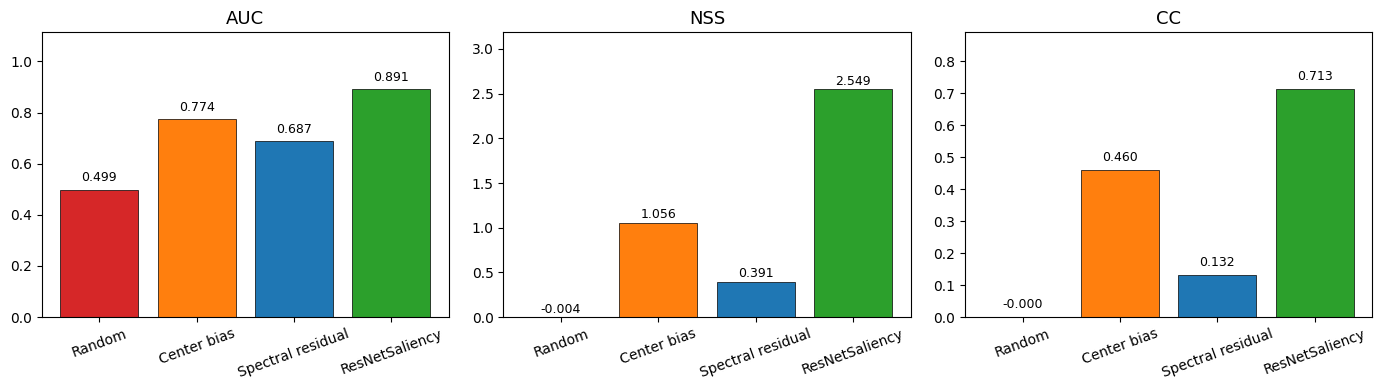

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c']
labels = ['Random', 'Center bias', 'Spectral residual', 'ResNetSaliency']

for ax, metric in zip(axes, ['AUC', 'NSS', 'CC']):
    bars = ax.bar(labels, df[metric], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(metric, fontsize=13)
    ax.set_ylim(0, df[metric].max() * 1.25)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Conclusion

**SaccadeJEPA is not a gaze simulator!** Its saccade targets are uniformly random (AUC = 0.499, chance level).

**Replacing the random line with ResNetSaliency** produces gaze patterns that closely match human fixation data:

| Metric | Random | ResNetSaliency | Improvement |
|---|---|---|---|
| AUC | 0.499 | **0.891** | +78% toward perfect |
| NSS | -0.004 | **2.549** | fixations 2.5 std above average |
| CC  | 0.000 | **0.713** | strong spatial correlation with GT |

**Limitation:** ResNetSaliency's strength on FIND is largely driven by ImageNet-pretrained face detection features. Since FIND is a social video dataset where gaze is dominated by faces, face-aware features are highly predictive here. Fine-tuning the full backbone on a larger and more diverse gaze dataset would yield a model that generalizes beyond social scenes.